In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

video_dirs = {
    "train_val": fr"D:\AI-Video-Captioning-In-Nepali-Using-Transformers\msvd_dataset_std_1200_100_670_split\videos_train_val",
    "test": fr"D:\AI-Video-Captioning-In-Nepali-Using-Transformers\msvd_dataset_std_1200_100_670_split\videos_test"
}

data = []

for split_name, video_dir in video_dirs.items():
    for filename in os.listdir(video_dir):
        if filename.endswith(".avi"):
            video_path = os.path.join(video_dir, filename)
            cap = cv2.VideoCapture(video_path)

            if not cap.isOpened():
                print(f"Could not open {video_path}")
                continue

            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

            if fps is None or fps <= 0:
                print(f"Invalid FPS for {video_path}")
                cap.release()
                continue

            duration = frame_count / fps

            data.append({
                "split": split_name,
                "video_name": filename,
                "fps": fps,
                "frame_count": frame_count,
                "duration_sec": duration
            })

            cap.release()

df = pd.DataFrame(data)

print(df.head())
print(df.groupby("split")["duration_sec"].describe())

       split                     video_name        fps  frame_count  \
0  train_val     00001_nULE40HEWpA_5_11.avi  15.000000         91.0   
1  train_val    00001_QOmrchUPnBs_10_20.avi  29.970030        300.0   
2  train_val  00002_0lh_UWF9ZP4_199_207.avi  29.916667        240.0   
3  train_val     00002_xXlWsBhFvis_6_10.avi  29.970030        120.0   
4  train_val     00003_BGG0uYWZBdw_6_12.avi  29.970030        180.0   

   duration_sec  
0      6.066667  
1     10.010000  
2      8.022284  
3      4.004000  
4      6.006000  
            count      mean       std       min    25%       50%     75%  \
split                                                                      
test        670.0  9.714291  6.365988  2.005571  6.006  8.033333  11.011   
train_val  1300.0  9.612234  6.084729  1.735067  6.006  8.022284  11.011   

                 max  
split                 
test       50.033333  
train_val  60.026633  


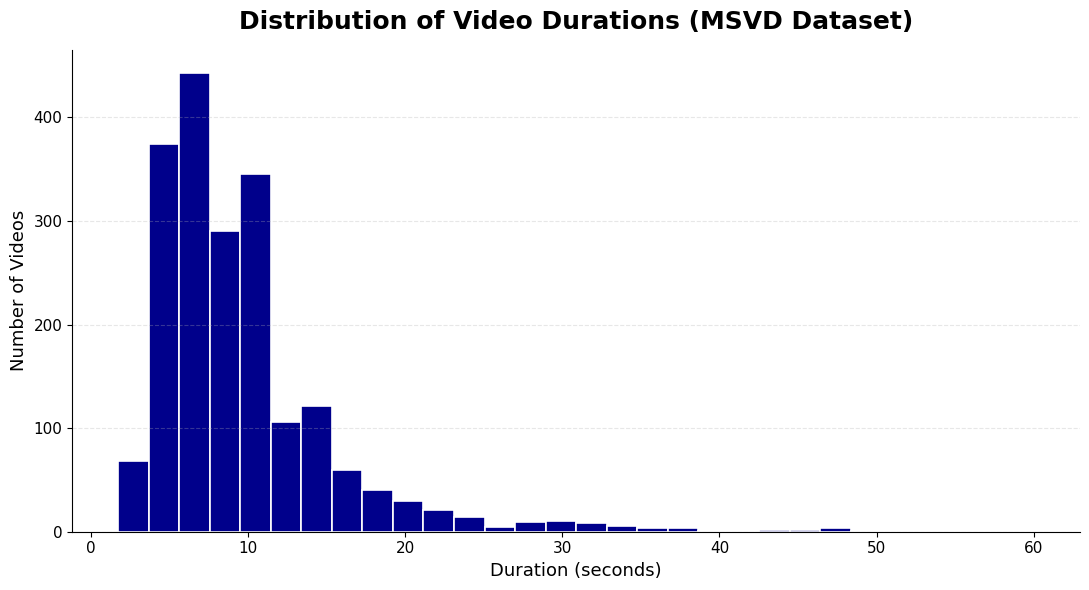

In [2]:
plt.figure(figsize=(11, 6))
plt.hist(
    df["duration_sec"],
    bins=30,
    edgecolor="white",
    linewidth=1.2,
    color = "darkblue"
)

plt.title("Distribution of Video Durations (MSVD Dataset)", fontsize=18, pad=15, weight="bold")
plt.xlabel("Duration (seconds)", fontsize=13)
plt.ylabel("Number of Videos", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_linewidth(0.8)
plt.gca().spines["bottom"].set_linewidth(0.8)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.style.use("ggplot")
plt.show()

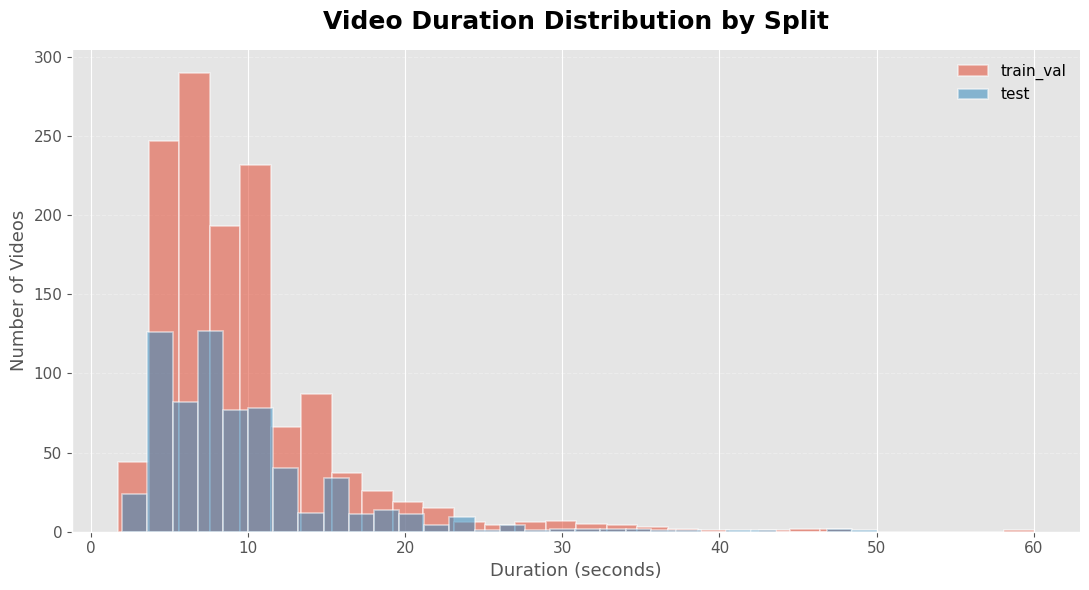

In [3]:
plt.figure(figsize=(11, 6))

for split in df["split"].unique():
    subset = df[df["split"] == split]
    plt.hist(
        subset["duration_sec"],
        bins=30,
        alpha=0.55,
        edgecolor="white",
        linewidth=1.2,
        label=split
    )

plt.title("Video Duration Distribution by Split", fontsize=18, pad=15, weight="bold")
plt.xlabel("Duration (seconds)", fontsize=13)
plt.ylabel("Number of Videos", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()